# House Price Prediction


###  Data Loading & Exploration

In [124]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor


In [125]:
# Load the CSV file using Pandas

df = pd.read_csv('Housing.csv')

In [126]:
# Display the first 10 rows of the DataFrame
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [127]:
# Display the number of rows and columns in the DataFrame, as well as the feature columns 

row, col = df.shape
print(f"Number of rows: {row}")
print(f"Number of columns: {col}")
print(f'Feature columns: {[c for c in df.columns if c != "price"]}')

Number of rows: 545
Number of columns: 13
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


### Data Cleaning

In [128]:
# Check for missing values in the DataFrame

df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [129]:
# Check for duplicate rows in the DataFrame

duplicates = df[df.duplicated(keep=False)]
print(duplicates)
df.drop_duplicates()

Empty DataFrame
Columns: [price, area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus]
Index: []


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [130]:
# Convert binary categorical columns to numerical values 

bin_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in bin_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [131]:
# Encode the 'furnishingstatus' column using one-hot encoding

if 'furnishingstatus' in df.columns:
    df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=False)
    df.rename(columns={
        'furnishingstatus_furnished':      'furnished',
        'furnishingstatus_semi-furnished': 'semi_furnished',
        'furnishingstatus_unfurnished':    'unfurnished'
    }, inplace=True)
else:
    print("Already encoded — skipping.")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnished,semi_furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False


### Model Building

In [132]:
#  Split the data into training and test sets (80/20)

x = df.drop('price', axis=1)
y = df['price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train a Linear Regression model to predict house price

l = LinearRegression()
l.fit(x_train, y_train)
y_pred_lr = l.predict(x_test)

# Evaluate it using MAE, RMSE, and R² Score

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)
print(f'MAE is Rs. {mae:,.0f}')
print(f'RMSE is Rs. {rmse:,.0f}')
print(f'R² is {r2:.4f}')

MAE is Rs. 970,043
RMSE is Rs. 1,324,507
R² is 0.6529


In [ ]:
#  Train a second model — Random Forest Regressor

r = RandomForestRegressor(n_estimators=200, random_state=42)
r.fit(x_train, y_train)
y_pred_rf = r.predict(x_test)

mae_r  = mean_absolute_error(y_test, y_pred_rf)
rmse_r = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_r   = r2_score(y_test, y_pred_rf)

print(f'MAE is Rs. {mae_r:,.0f}')
print(f'RMSE is Rs. {rmse_r:,.0f}')
print(f'R² is {r2_r:.4f}')

MAE is Rs. 1,009,083
RMSE is Rs. 1,391,456
R² is 0.6170


In [ ]:
# compare random forest to the Linear Regression model

comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Linear Regression': [f'₹{mae:,.0f}', f'₹{rmse:,.0f}', f'{r2:.4f}'],
    'Random Forest':     [f'₹{mae_r:,.0f}', f'₹{rmse_r:,.0f}', f'{r2_r:.4f}']
})
comparison

,Metric,Linear Regression,Random Forest
0,MAE,"₹970,043","₹1,009,083"
1,RMSE,"₹1,324,507","₹1,391,456"
2,R² Score,0.6529,0.6170


### Visualization

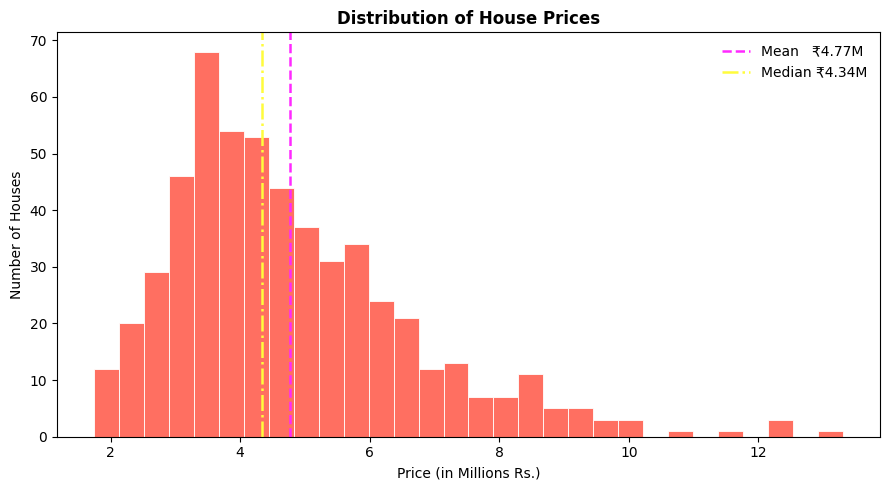

In [ ]:
# Histogram of house prices distribution

fig, x = plt.subplots(figsize=(9, 5))
ACCENT = '#FF6F61'
x.hist(df['price'] / 1e6, bins=30, color=ACCENT, edgecolor='white', linewidth=0.6)
x.set_xlabel('Price (in Millions Rs.)')
x.set_ylabel('Number of Houses')
x.set_title('Distribution of House Prices', fontweight='bold')
x.axvline(df['price'].mean() / 1e6,   color="#FF29FF",    linestyle='--', linewidth=1.8, label=f'Mean   ₹{df["price"].mean()/1e6:.2f}M')
x.axvline(df['price'].median() / 1e6, color="#FFFC3C", linestyle='-.', linewidth=1.8, label=f'Median ₹{df["price"].median()/1e6:.2f}M')
x.legend(frameon=False)
plt.tight_layout()
plt.savefig('house_price_distribution.png')
plt.show()


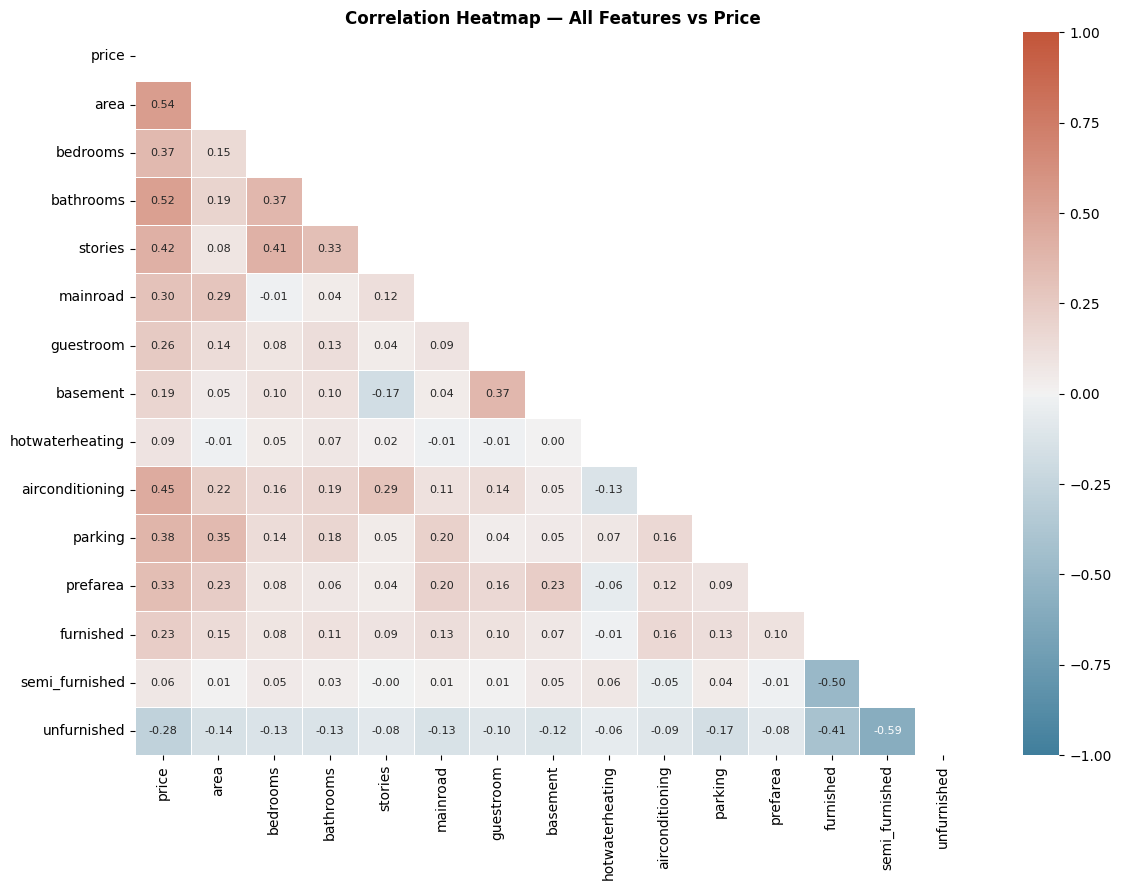

In [ ]:
# Correlation Heatmap of all features vs price

fig, x = plt.subplots(figsize=(12, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 8}, ax=x)
x.set_title('Correlation Heatmap — All Features vs Price', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

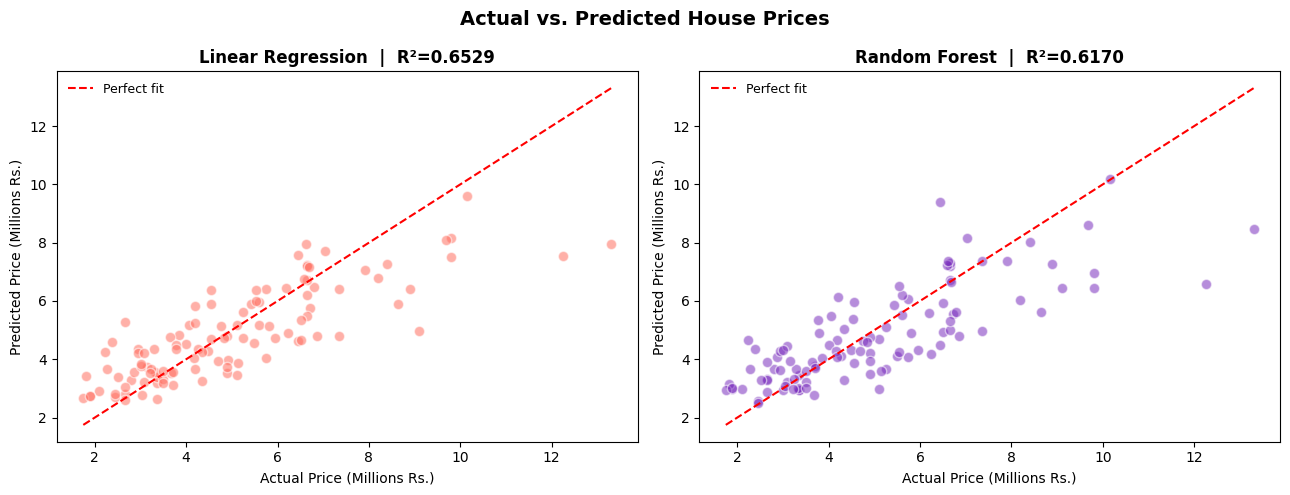

In [ ]:
# Actual vs. Predicted House Prices

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for x, y_pred, title, color in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Linear Regression', 'Random Forest'],
    [ACCENT, '#7B2FBE']
):
    x.scatter(y_test / 1e6, y_pred / 1e6, alpha=0.55, color=color, edgecolors='white', s=55)
    mn = min(y_test.min(), y_pred.min()) / 1e6
    mx = max(y_test.max(), y_pred.max()) / 1e6
    x.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    x.set_xlabel('Actual Price (Millions Rs.)')
    x.set_ylabel('Predicted Price (Millions Rs.)')
    x.set_title(f'{title}  |  R²={r2_score(y_test, y_pred):.4f}', fontweight='bold')
    x.legend(frameon=False, fontsize=9)
plt.suptitle('Actual vs. Predicted House Prices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

### Insights

**Q1.  Which features influence house price the most?**

ANS. According to given dataset, Area has the most influence in predicting the house price. Also, number of bathrooms, air-conditioning and location has a good influence on house price.


**Q2. How accurate was the model?**

ANS. In linear Regression, R² is 0.6529 i.e., there is a 65% of the variance in house prices whereas R² is 0.617 showing that the relationships in this dataset are largely linear.

**Q3. What surprised you?**  

ANS. Dataset has no duplicate rows aor missing values. Also, The guestroom and basement features has very weak correlation with price whereas air-conditioning and bathrooms carry far more weight with buyers in this dataset.

**Q4. Recommendation for a real estate business**  

ANS. Listings should prominently feature total area and the number of bathrooms as primary value drivers. Properties in preferred areas with air-conditioning consistently command premium prices i.e., agents should use these attributes to justify higher asking prices, prioritise such properties for marketing investment, and counsel sellers to invest in air-conditioning as a high-ROI upgrade before listing.
